# Exploratory Data Visualization



In [75]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

df = pd.read_csv("Sleep_health_and_lifestyle_dataset.csv")
df.head()


,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,NaN
1,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
2,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea


## 1. Basic Distributions of Key Variables
- We first examine the distribution of sleep duration, sleep quality, stress, and physical activity.

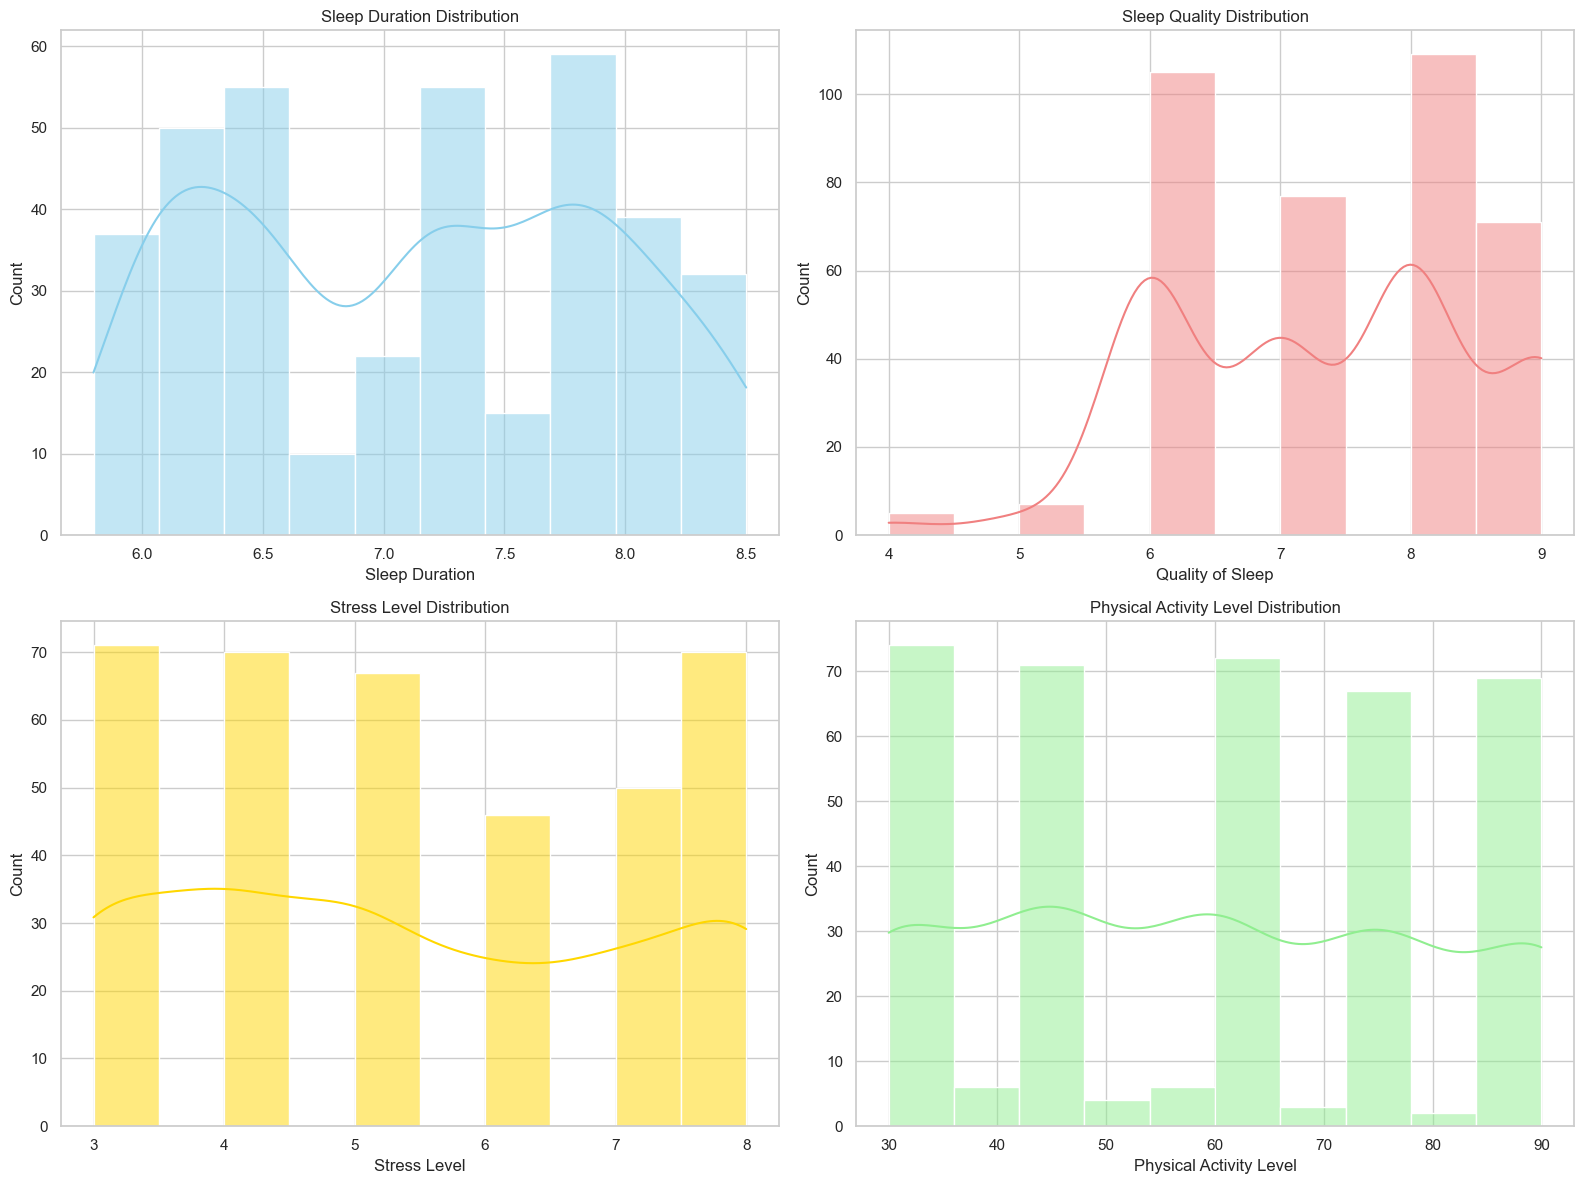

In [76]:
# 
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

sns.histplot(df["Sleep Duration"], kde=True, ax=axes[0,0], color="skyblue")
axes[0,0].set_title("Sleep Duration Distribution")

sns.histplot(df["Quality of Sleep"], kde=True, ax=axes[0,1], color="lightcoral")
axes[0,1].set_title("Sleep Quality Distribution")

sns.histplot(df["Stress Level"], kde=True, ax=axes[1,0], color="gold")
axes[1,0].set_title("Stress Level Distribution")

sns.histplot(df["Physical Activity Level"], kde=True, ax=axes[1,1], color="lightgreen")
axes[1,1].set_title("Physical Activity Level Distribution")

plt.tight_layout()
plt.show()


The distributions of sleep duration, sleep quality, stress level, and physical activity show that most values fall in normal, expected ranges.

- **Sleep Duration** is mostly between 6–8 hours, suggesting that most participants get a reasonable amount of sleep.
- **Sleep Quality** tends to cluster between 6 and 9, indicating many people feel they sleep fairly well.
- **Stress Level** varies more widely, but many individuals report mid-to-high stress.
- **Physical Activity** ranges from about 30 to 80 minutes per day, showing that the sample is generally active, with no extreme outliers.

Overall, these distributions suggest a fairly healthy population with balanced lifestyle characteristics.


## 2. Sleep Disorder Counts

/var/folders/r2/nx6nxs1j1zz1s1t0c5m5fftr0000gn/T/ipykernel_91869/3375504058.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="Sleep Disorder", palette="pastel")


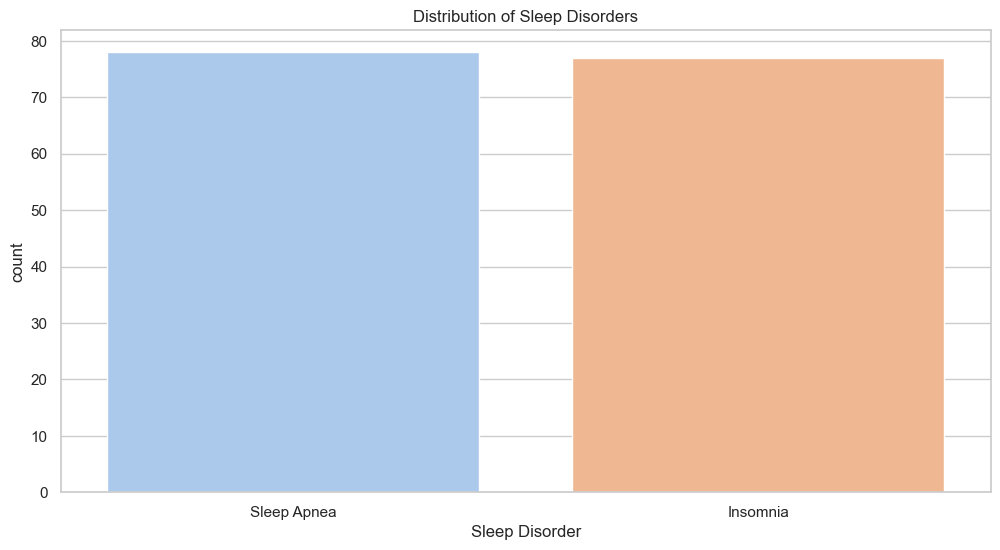

In [77]:

sns.countplot(data=df, x="Sleep Disorder", palette="pastel")
plt.title("Distribution of Sleep Disorders")
plt.show()


Most individuals report **no sleep disorder**, while the two main conditions recorded are **Sleep Apnea** and **Insomnia**.

- “None” is the dominant category.
- Sleep Apnea appears slightly more common than Insomnia.
- There are very few missing values.

This indicates that while sleep disorders exist in the dataset, the majority do not report one, which could create class imbalance in predictive models.


## 3. Sleep Duration by Gender and BMI

/var/folders/r2/nx6nxs1j1zz1s1t0c5m5fftr0000gn/T/ipykernel_91869/1792121035.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Gender", y="Sleep Duration", ax=ax[0], palette="Set2")
/var/folders/r2/nx6nxs1j1zz1s1t0c5m5fftr0000gn/T/ipykernel_91869/1792121035.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="BMI Category", y="Sleep Duration", ax=ax[1], palette="Set3")


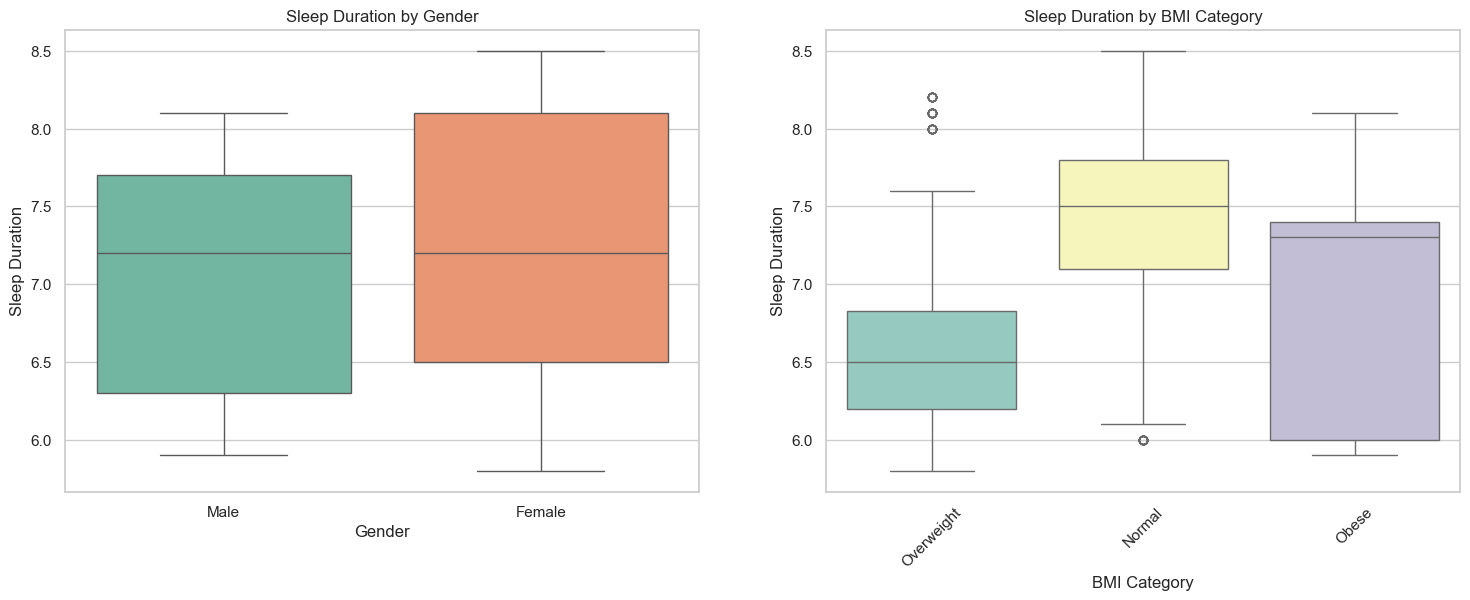

In [78]:
# Combine normal
df["BMI Category"] = df["BMI Category"].replace({
    "Normal Weight": "Normal"
})

fig, ax = plt.subplots(1, 2, figsize=(18, 6))

sns.boxplot(data=df, x="Gender", y="Sleep Duration", ax=ax[0], palette="Set2")
ax[0].set_title("Sleep Duration by Gender")

sns.boxplot(data=df, x="BMI Category", y="Sleep Duration", ax=ax[1], palette="Set3")
ax[1].set_title("Sleep Duration by BMI Category")
ax[1].tick_params(axis="x", rotation=45)

plt.show()


- **Gender:** Both males and females have very similar sleep duration patterns. There is no major difference between groups.
- **BMI Category:** People classified as **Obese** tend to sleep slightly less on average. Meanwhile, individuals in the Normal and Overweight groups show similar sleep durations.

This suggests that BMI may have a small effect on sleep habits, whereas gender does not seem to influence sleep duration in any meaningful way.


## 4. Stress vs Sleep Duration / Sleep Quality

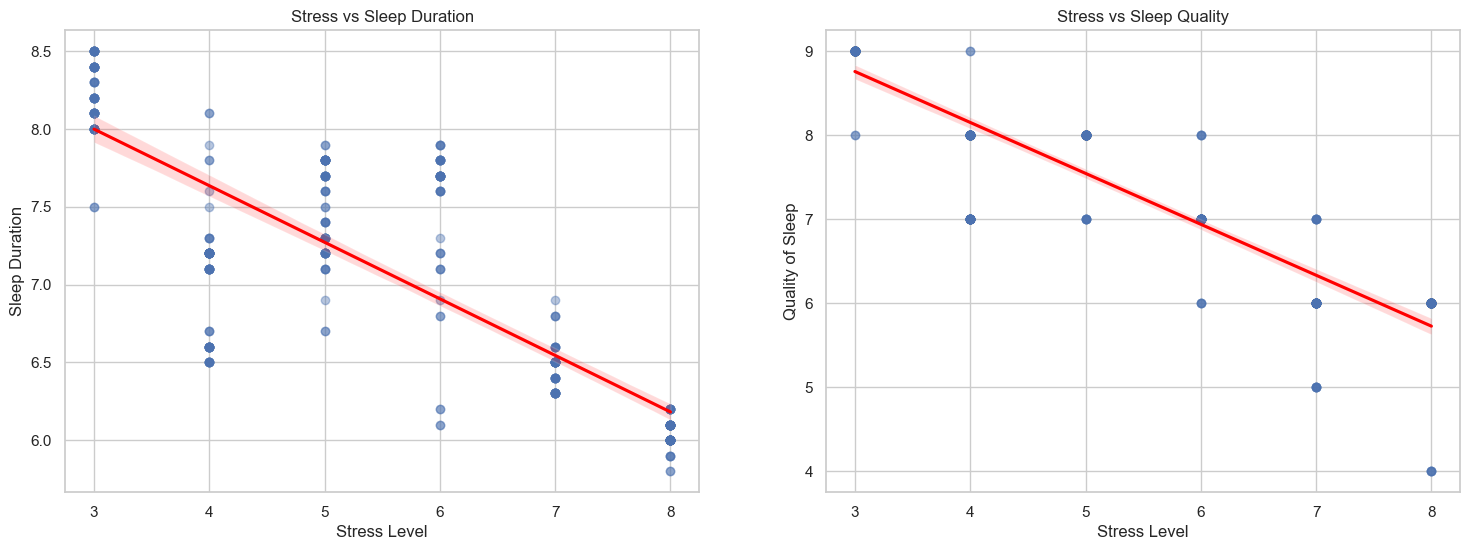

In [79]:
fig, ax = plt.subplots(1, 2, figsize=(18, 6))

sns.regplot(data=df, x="Stress Level", y="Sleep Duration",
            ax=ax[0], scatter_kws={"alpha":0.4}, line_kws={"color":"red"})
ax[0].set_title("Stress vs Sleep Duration")

sns.regplot(data=df, x="Stress Level", y="Quality of Sleep",
            ax=ax[1], scatter_kws={"alpha":0.4}, line_kws={"color":"red"})
ax[1].set_title("Stress vs Sleep Quality")

plt.show()


There is a clear negative relationship between stress and sleep outcomes:

- As **stress levels increase**, both **sleep duration** and **sleep quality** decrease.
- The scatter plots show strong downward trends, meaning that people with high stress tend to sleep less and report worse rest.

This is one of the strongest patterns in the entire dataset and highlights the important role of stress in determining sleep health.

## 5. Correlation Heatmap

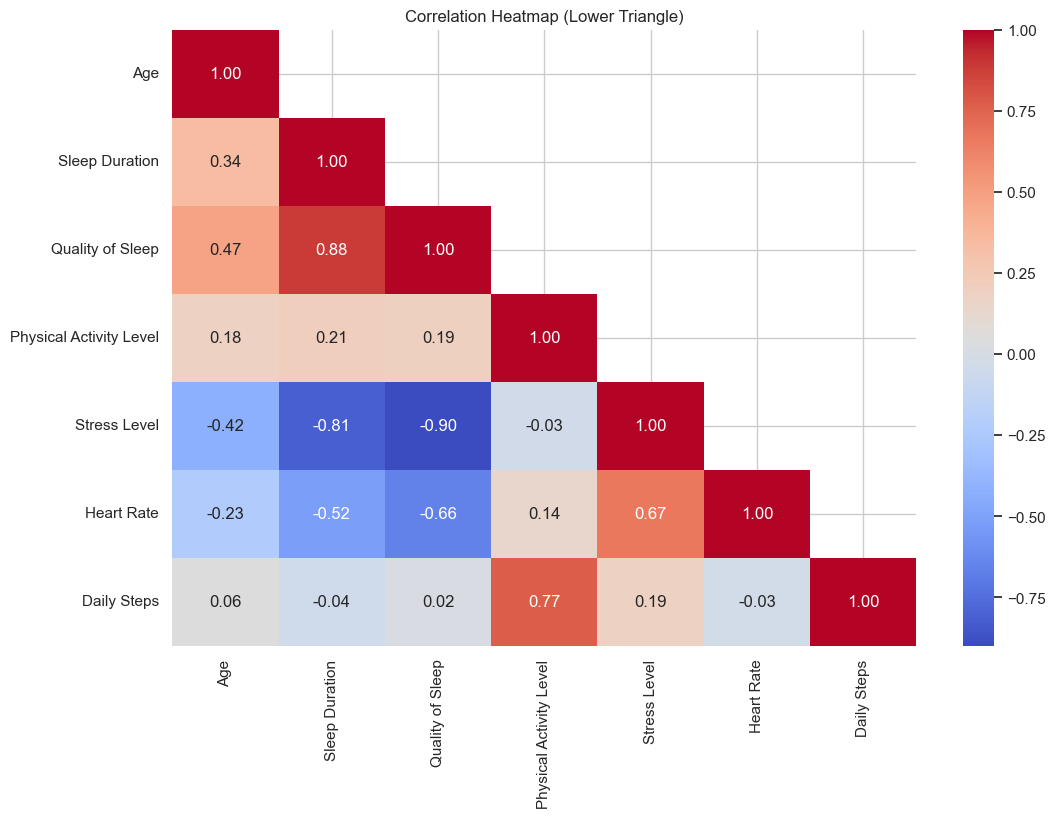

In [80]:
numeric_cols = [
    "Age",
    "Sleep Duration",
    "Quality of Sleep",
    "Physical Activity Level",
    "Stress Level",
    "Heart Rate",
    "Daily Steps"
]

corr = df[numeric_cols].corr()

# --- Create triangle mask ---
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)

plt.figure(figsize=(12, 8))
sns.heatmap(
    corr, 
    mask=mask,
    annot=True, 
    cmap="coolwarm", 
    fmt=".2f"
)
plt.title("Correlation Heatmap (Lower Triangle)")
plt.show()


Several key relationships stand out:

- **Sleep Duration ↔ Sleep Quality** has a strong positive correlation. People who sleep longer generally report better sleep quality.
- **Stress Level** has strong negative correlations with both sleep duration and sleep quality.  
- **Daily Steps ↔ Physical Activity** have a strong positive correlation, which makes intuitive sense.
- **Heart Rate ↔ Stress** is moderately positive, showing that people with higher stress also tend to have higher heart rates.
- Age shows very weak correlations with almost everything.

These relationships show that stress plays a major role in sleep, while physical activity and steps are closely tied but don’t strongly affect sleep outcomes.


## 6. Sleep Quality Across Occupations

In [81]:
df["Occupation"].value_counts()

Occupation
Nurse                   73
Doctor                  71
Engineer                63
Lawyer                  47
Teacher                 40
Accountant              37
Salesperson             32
Software Engineer        4
Scientist                4
Sales Representative     2
Manager                  1
Name: count, dtype: int64

Some occupations does not have enough data, drop them.

In [82]:
min_count = 10

# Find occupations that meet the threshold
valid_occ = df['Occupation'].value_counts()
valid_occ = valid_occ[valid_occ >= min_count].index

# Filter the DataFrame
df = df[df['Occupation'].isin(valid_occ)]
df["Occupation"].value_counts()

Occupation
Nurse          73
Doctor         71
Engineer       63
Lawyer         47
Teacher        40
Accountant     37
Salesperson    32
Name: count, dtype: int64

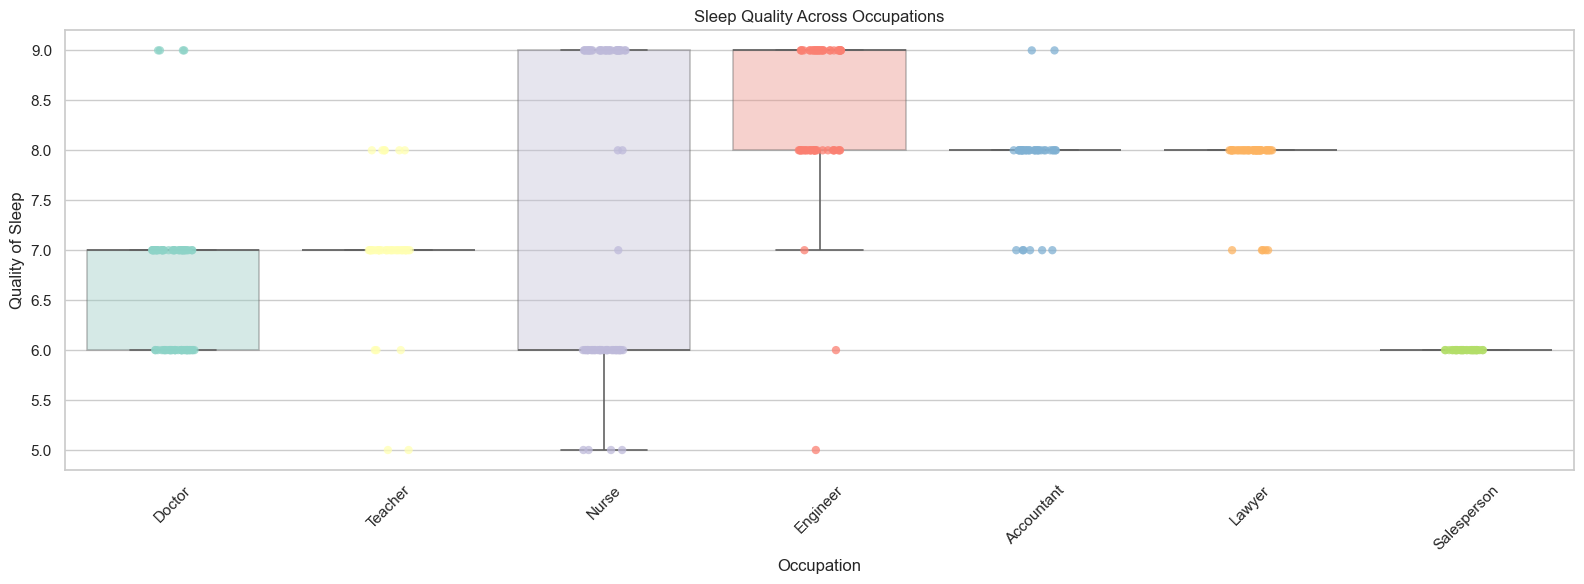

In [83]:
top_occ = df["Occupation"].value_counts().head(10).index

plt.figure(figsize=(16, 6))

# Generate a color palette matching the number of occupations
occupations = df["Occupation"].unique()
palette = sns.color_palette("Set3", n_colors=len(occupations))
color_map = dict(zip(occupations, palette))

# Boxplot with matching colors
sns.boxplot(
    data=df,
    x="Occupation",
    y="Quality of Sleep",
    hue="Occupation",
    palette=color_map,
    dodge=False,
    boxprops={"alpha": 0.4},    # slightly transparent
    linewidth=1.2,
    showfliers=False,          # hide outliers to avoid clutter
    legend=False
)

# Overlay stripplot (raw points)
sns.stripplot(
    data=df,
    x="Occupation",
    y="Quality of Sleep",
    hue="Occupation",
    palette=color_map,
    dodge=False,
    alpha=0.75,
    size=6,
    legend=False
)

plt.xticks(rotation=45)
plt.title("Sleep Quality Across Occupations")
plt.tight_layout()
plt.show()



Sleep quality varies across job types:

- Healthcare jobs (Nurse, Doctor) show a moderate level of sleep quality, with noticeable variation.
- Jobs like Engineer and Accountant tend to have slightly more consistent and higher sleep quality.
- Occupations with very few samples (e.g., Manager, Sales Representative) are harder to interpret.

This suggests that occupation-related routine or stress levels may influence sleep quality, but sample size differences should be considered.


## 7. Lifestyle Radar Plot

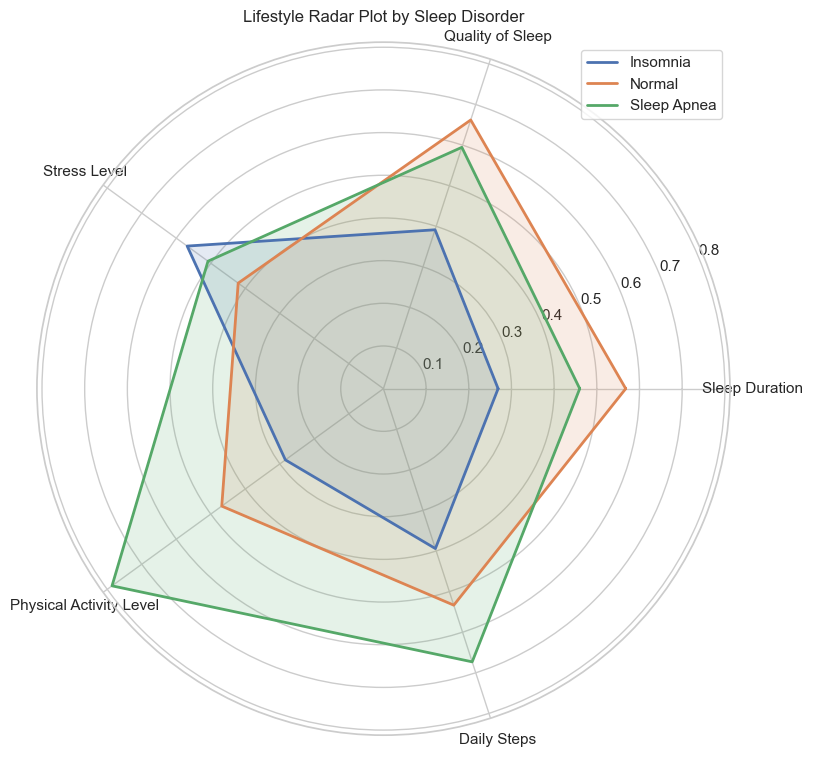

In [84]:

import numpy as np


# Normalize Sleep Disorder labels so "None" is changed to "Normal"
df["Sleep Disorder"] = df["Sleep Disorder"].fillna("Normal")
df["Sleep Disorder"] = df["Sleep Disorder"].replace({
    "none": "Normal",
    "NONE": "Normal",
    "": "Normal"
})

radar_cols = [
    "Sleep Duration",
    "Quality of Sleep",
    "Stress Level",
    "Physical Activity Level",
    "Daily Steps"
]

df_norm = df.copy()
for col in radar_cols:
    df_norm[col] = (df[col] - df[col].min()) / (df[col].max() - df[col].min())

grouped = df_norm.groupby("Sleep Disorder")[radar_cols].mean()

labels = radar_cols
angles = np.linspace(0, 2*np.pi, len(labels), endpoint=False).tolist()
angles += angles[:1]

fig = plt.figure(figsize=(9, 9))
ax = plt.subplot(111, polar=True)

for disorder in grouped.index:
    values = grouped.loc[disorder].tolist()
    values += values[:1]
    ax.plot(angles, values, linewidth=2, label=disorder)
    ax.fill(angles, values, alpha=0.15)

plt.xticks(angles[:-1], labels)
plt.title("Lifestyle Radar Plot by Sleep Disorder")
plt.legend(loc="best")
plt.show()


Comparing Insomnia and Sleep Apnea groups:

- **Insomnia:**  
  - Higher stress levels  
  - Lower sleep duration  
  - Slightly lower daily steps and physical activity  
- **Sleep Apnea:**  
  - Higher physical activity and daily steps  
  - Also lower sleep quality but for likely different, more physiological reasons

The radar plot shows that insomnia is more closely tied to stress-related issues, while sleep apnea seems to relate more to physical or biological factors.


## **Overall Summary**
Across all the visualizations, a few patterns repeat clearly:

- **Stress is the strongest factor** that negatively affects both sleep duration and sleep quality.
- **Physical activity** relates strongly to daily steps but does not strongly influence sleep.
- **BMI and occupation** play smaller but still noticeable roles.
- **Sleep disorders** show distinct lifestyle patterns, especially when comparing insomnia and sleep apnea.

These insights give a good foundation for further modeling or deeper investigation into the causes of poor sleep.

# 9. Occupation and Sleep Quality Analysis

## 9.1 Sleep Debt by Occupation
We define **Sleep Debt** as the difference between the recommended sleep duration (assumed to be 8 hours) and the actual sleep duration. A positive value indicates sleep debt (less than 8 hours), while a negative value indicates surplus sleep.

/var/folders/r2/nx6nxs1j1zz1s1t0c5m5fftr0000gn/T/ipykernel_91869/1326605127.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Occupation', y='Sleep Debt', data=occupation_sleep_debt, palette='coolwarm')


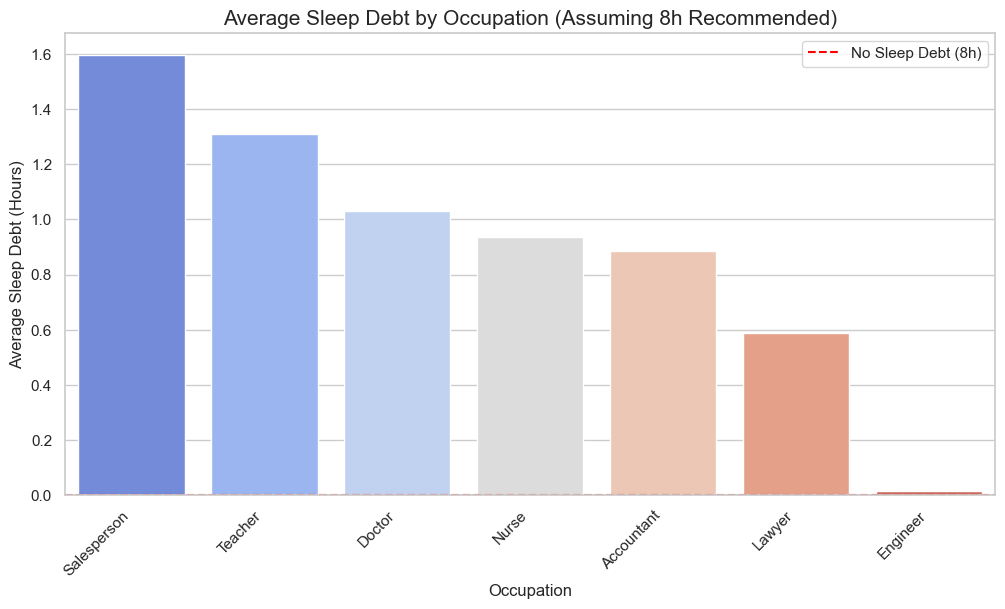

In [85]:
# Calculate Sleep Debt
df['Sleep Debt'] = 8 - df['Sleep Duration']

# Calculate Average Sleep Debt by Occupation
occupation_sleep_debt = df.groupby('Occupation')['Sleep Debt'].mean().sort_values(ascending=False).reset_index()

# Visualization
plt.figure(figsize=(12, 6))
sns.barplot(x='Occupation', y='Sleep Debt', data=occupation_sleep_debt, palette='coolwarm')
plt.title('Average Sleep Debt by Occupation (Assuming 8h Recommended)', fontsize=15)
plt.ylabel('Average Sleep Debt (Hours)', fontsize=12)
plt.xlabel('Occupation', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.axhline(0, color='red', linestyle='--', label='No Sleep Debt (8h)')
plt.legend()
plt.show()

## 9.2 Behavioral Factors Analysis
We examine behavioral factors such as Physical Activity, Stress Level, and BMI to understand their relationship with Occupation and Sleep.

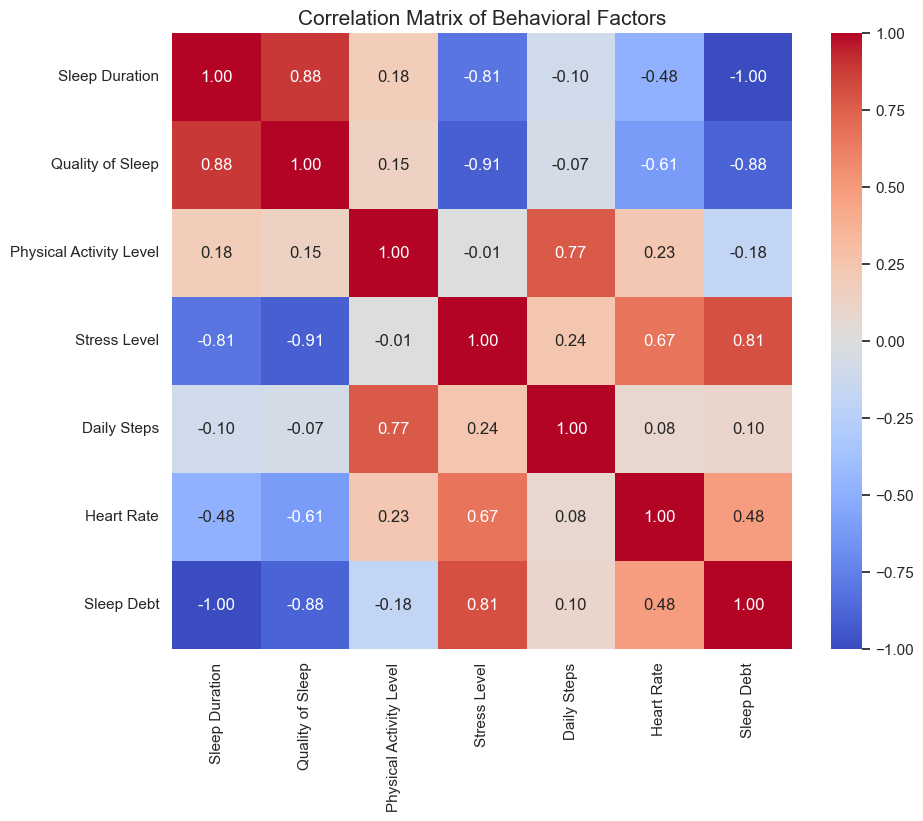

In [86]:
# Correlation Matrix of Behavioral Factors
behavioral_cols = ['Sleep Duration', 'Quality of Sleep', 'Physical Activity Level', 'Stress Level', 'Daily Steps', 'Heart Rate', 'Sleep Debt']
corr_matrix = df[behavioral_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Behavioral Factors', fontsize=15)
plt.show()

/var/folders/r2/nx6nxs1j1zz1s1t0c5m5fftr0000gn/T/ipykernel_91869/508032667.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Occupation', y='Stress Level', data=df, palette='coolwarm', ax=axes[0])
/var/folders/r2/nx6nxs1j1zz1s1t0c5m5fftr0000gn/T/ipykernel_91869/508032667.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Occupation', y='Physical Activity Level', data=df, palette='coolwarm', ax=axes[1])


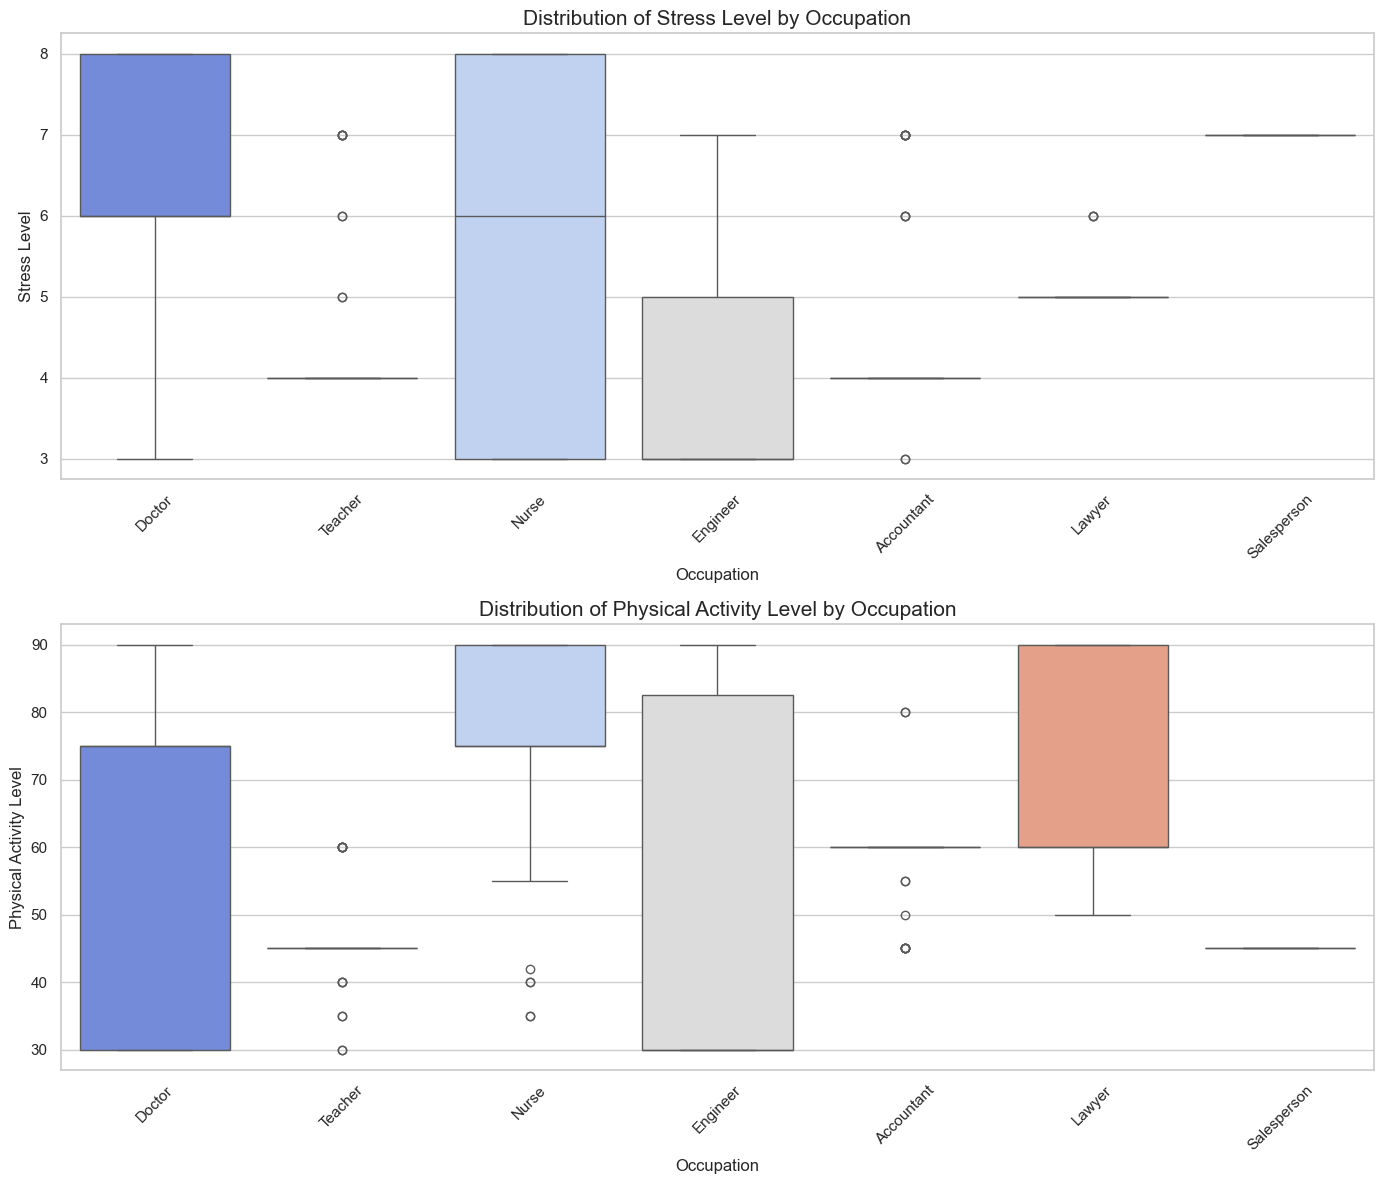

In [87]:
# Stress Level and Physical Activity by Occupation
fig, axes = plt.subplots(2, 1, figsize=(14, 12))

sns.boxplot(x='Occupation', y='Stress Level', data=df, palette='coolwarm', ax=axes[0])
axes[0].set_title('Distribution of Stress Level by Occupation', fontsize=15)
axes[0].tick_params(axis='x', rotation=45)

sns.boxplot(x='Occupation', y='Physical Activity Level', data=df, palette='coolwarm', ax=axes[1])
axes[1].set_title('Distribution of Physical Activity Level by Occupation', fontsize=15)
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

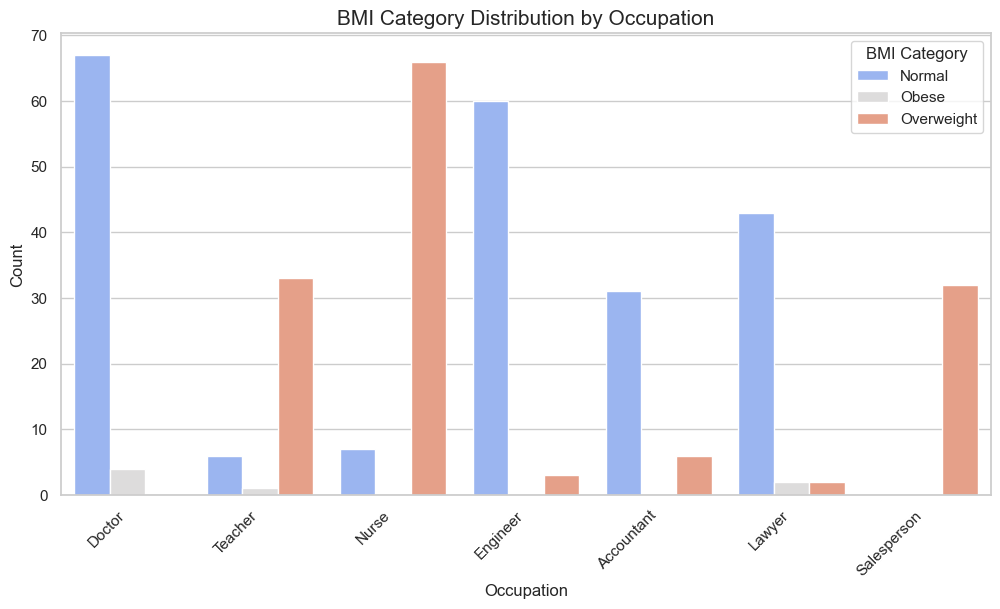

In [88]:
# BMI Category by Occupation
plt.figure(figsize=(12, 6))
sns.countplot(x='Occupation', hue='BMI Category', data=df, palette='coolwarm')
plt.title('BMI Category Distribution by Occupation', fontsize=15)
plt.ylabel('Count', fontsize=12)
plt.xlabel('Occupation', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend(title='BMI Category', loc='upper right')
plt.show()

## 9.3 Sleep Quality vs Characteristics by Occupation
We analyze how Sleep Quality correlates with Sleep Duration across different occupations.

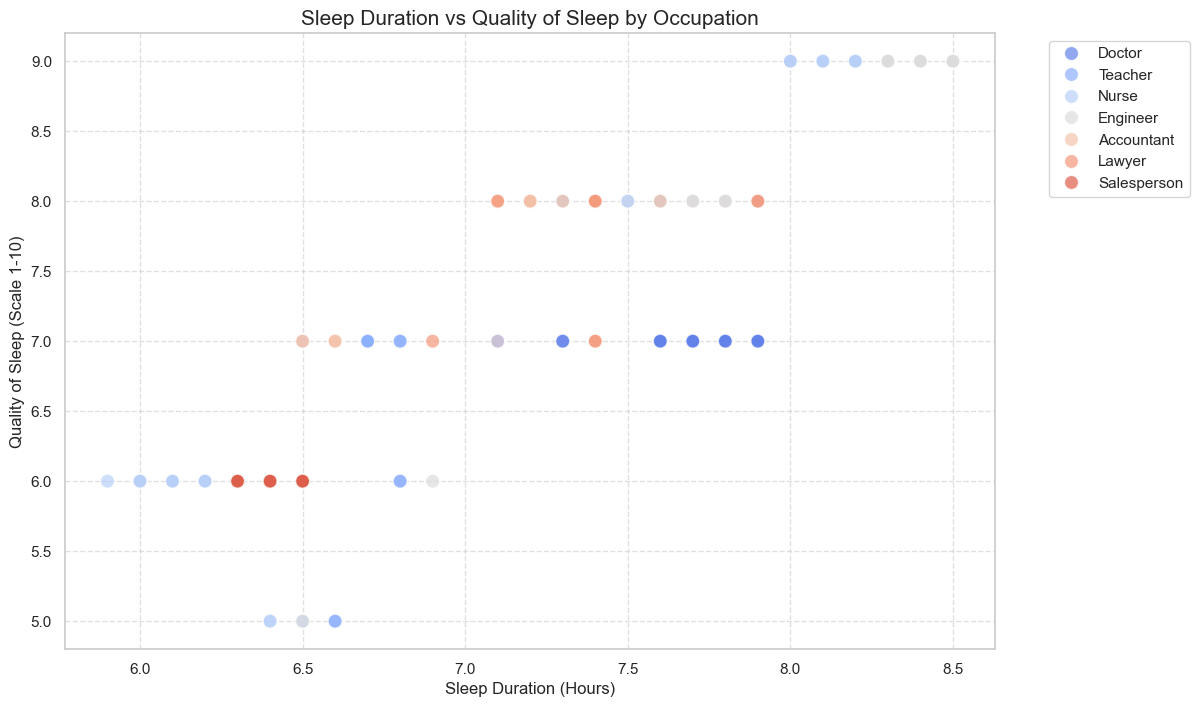

In [89]:
# Sleep Duration vs Quality of Sleep by Occupation
plt.figure(figsize=(12, 8))
sns.scatterplot(x='Sleep Duration', y='Quality of Sleep', hue='Occupation', data=df, palette='coolwarm', s=100, alpha=0.7)
plt.title('Sleep Duration vs Quality of Sleep by Occupation', fontsize=15)
plt.xlabel('Sleep Duration (Hours)', fontsize=12)
plt.ylabel('Quality of Sleep (Scale 1-10)', fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

/var/folders/r2/nx6nxs1j1zz1s1t0c5m5fftr0000gn/T/ipykernel_91869/2824386619.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Occupation', y='Quality of Sleep', data=df, palette='coolwarm')


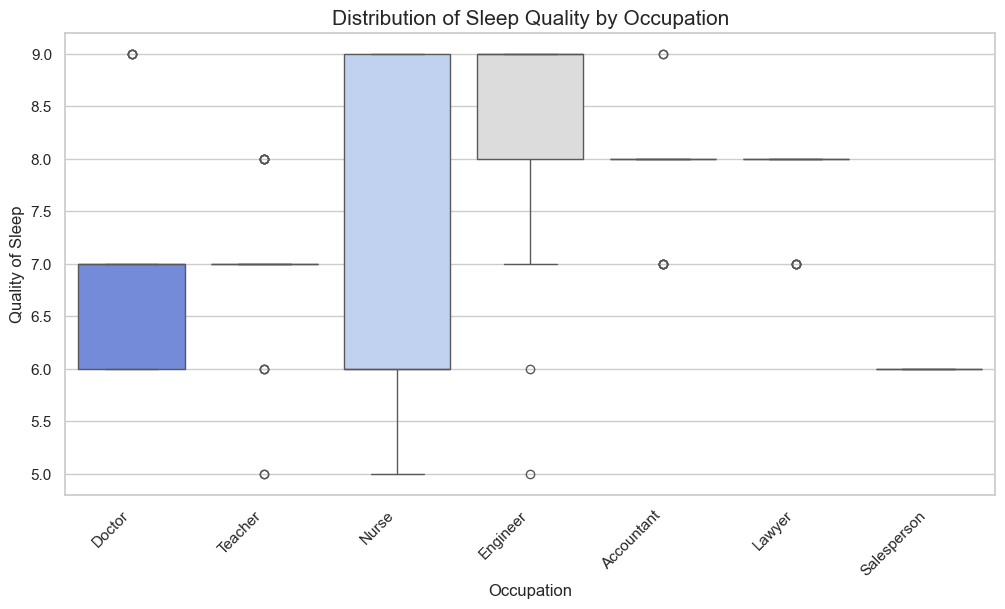

In [90]:
# Distribution of Sleep Quality by Occupation
plt.figure(figsize=(12, 6))
sns.boxplot(x='Occupation', y='Quality of Sleep', data=df, palette='coolwarm')
plt.title('Distribution of Sleep Quality by Occupation', fontsize=15)
plt.ylabel('Quality of Sleep', fontsize=12)
plt.xlabel('Occupation', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.show()

# 10. Occupation Group Analysis

We group occupations based on sleep quality patterns as hypothesized:
- **Group A (Stable)**: Accountant, Lawyer (High and stable sleep quality)
- **Group B (Variable)**: Nurse, Doctor (Variable sleep quality)
- **Group C (Poor)**: Salesperson, Sales Representative (Lower sleep quality)

We will verify these patterns and analyze the potential causes.

/var/folders/r2/nx6nxs1j1zz1s1t0c5m5fftr0000gn/T/ipykernel_91869/693252966.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Occupation Group', y='Quality of Sleep', data=df_groups, palette='coolwarm', order=['Group A (Stable)', 'Group B (Variable)', 'Group C (Poor)'])


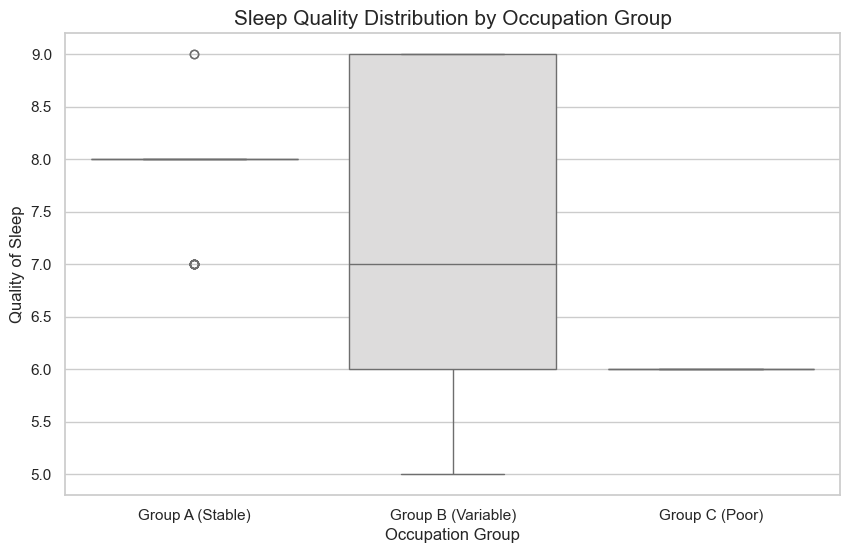

                        mean      std  count
Occupation Group                            
Group A (Stable)    7.892857  0.38080     84
Group B (Variable)  7.013889  1.27365    144
Group C (Poor)      6.000000  0.00000     32


In [91]:
# Define Occupation Groups
def get_occupation_group(occupation):
    if occupation in ['Accountant', 'Lawyer']:
        return 'Group A (Stable)'
    elif occupation in ['Nurse', 'Doctor']:
        return 'Group B (Variable)'
    elif occupation in ['Salesperson']:  # Removed Sales Representative
        return 'Group C (Poor)'
    else:
        return 'Other'

df['Occupation Group'] = df['Occupation'].apply(get_occupation_group)

# Filter for analysis (exclude 'Other' if needed, but keeping for context might be good. Let's focus on the 3 groups)
df_groups = df[df['Occupation Group'] != 'Other'].copy()

# Verify Sleep Quality Distribution by Group
plt.figure(figsize=(10, 6))
sns.boxplot(x='Occupation Group', y='Quality of Sleep', data=df_groups, palette='coolwarm', order=['Group A (Stable)', 'Group B (Variable)', 'Group C (Poor)'])
plt.title('Sleep Quality Distribution by Occupation Group', fontsize=15)
plt.show()

# Calculate Variance/Std Dev to quantify stability
group_stats = df_groups.groupby('Occupation Group')['Quality of Sleep'].agg(['mean', 'std', 'count'])
print(group_stats)


We analyze potential drivers for the observed sleep patterns by comparing Stress, Physical Activity, and BMI across the three groups.

## 10.1 Stress Levels
Group A: Stress levels are low(from 3 to 6), over 50% of those are between 4 and 5\
Group B: The range of stress levels is wide(from 3 to 8) \
Group C: Stress levels are high and consistent at 7

## 10.2 Physical Activity Levels
Group A: Most of the participants' physical activity levels are concentrated at 60\
Group B: Physical activity levels fluctuate from 30 to 90\
Group C: Physical activity levels are concentrated at around 45


/var/folders/r2/nx6nxs1j1zz1s1t0c5m5fftr0000gn/T/ipykernel_91869/735340034.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Occupation Group', y='Stress Level', data=df_groups, palette='coolwarm', order=['Group A (Stable)', 'Group B (Variable)', 'Group C (Poor)'])


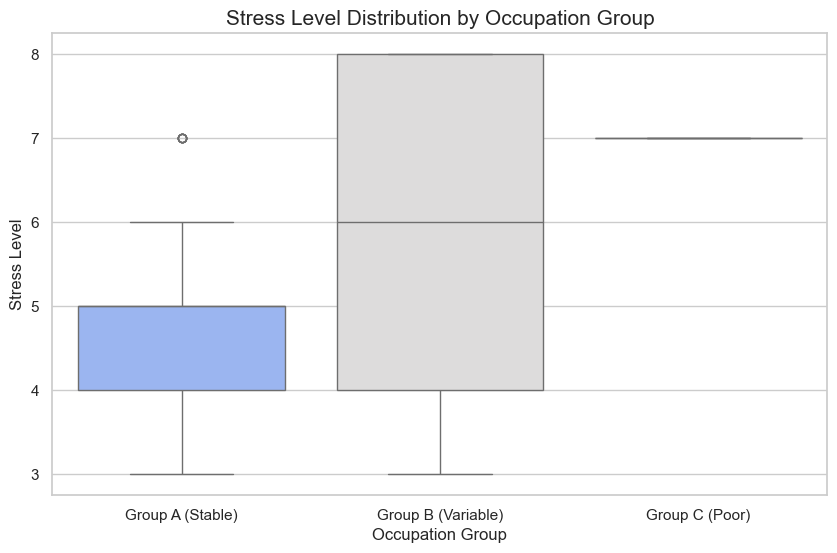

/var/folders/r2/nx6nxs1j1zz1s1t0c5m5fftr0000gn/T/ipykernel_91869/735340034.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Occupation Group', y='Physical Activity Level', data=df_groups, palette='coolwarm', order=['Group A (Stable)', 'Group B (Variable)', 'Group C (Poor)'])


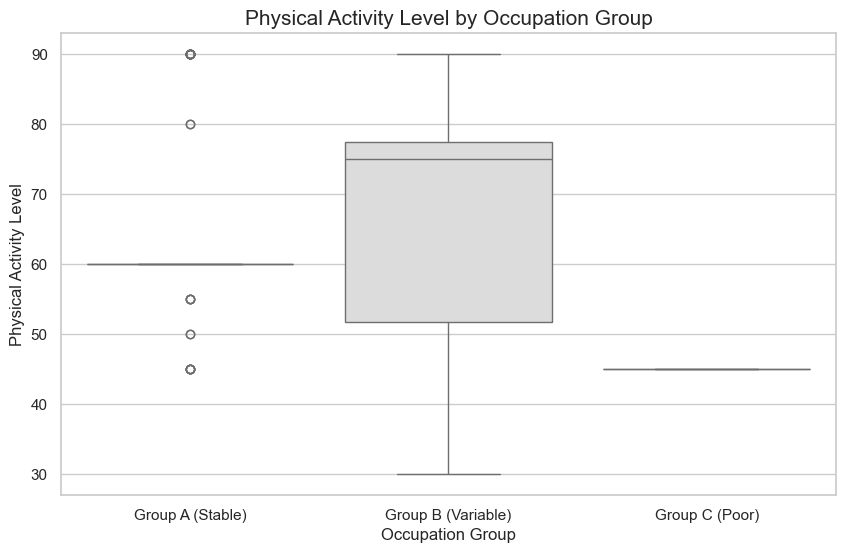

In [92]:
# Stress Level by Group
plt.figure(figsize=(10, 6))
sns.boxplot(x='Occupation Group', y='Stress Level', data=df_groups, palette='coolwarm', order=['Group A (Stable)', 'Group B (Variable)', 'Group C (Poor)'])
plt.title('Stress Level Distribution by Occupation Group', fontsize=15)
plt.show()

# Physical Activity by Group
plt.figure(figsize=(10, 6))
sns.boxplot(x='Occupation Group', y='Physical Activity Level', data=df_groups, palette='coolwarm', order=['Group A (Stable)', 'Group B (Variable)', 'Group C (Poor)'])
plt.title('Physical Activity Level by Occupation Group', fontsize=15)
plt.show()

## 10.3 BMI Category by Group 
Group A:  The vast majority fall into the Normal range\
Group B: Split between Normal and Overweight\
Group C: most people are in the obese weight range

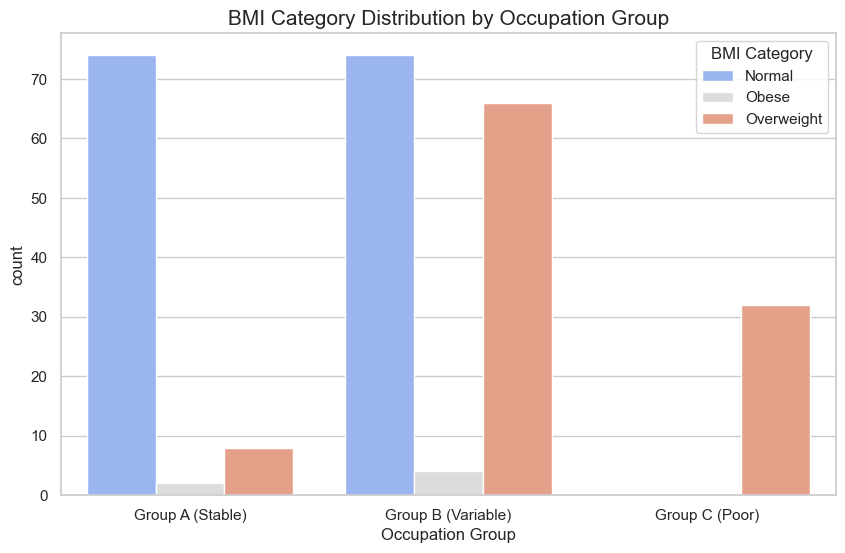

In [93]:
# BMI Category by Group
plt.figure(figsize=(10, 6))
sns.countplot(x='Occupation Group', hue='BMI Category', data=df_groups, palette='coolwarm', order=['Group A (Stable)', 'Group B (Variable)', 'Group C (Poor)'])
plt.title('BMI Category Distribution by Occupation Group', fontsize=15)
plt.legend(title='BMI Category', loc='upper right')
plt.show()

## 10.4 个人感觉无太大关联

/var/folders/r2/nx6nxs1j1zz1s1t0c5m5fftr0000gn/T/ipykernel_91869/3633200256.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Occupation Group', y='Age', data=df_groups, palette='coolwarm', order=['Group A (Stable)', 'Group B (Variable)', 'Group C (Poor)'])


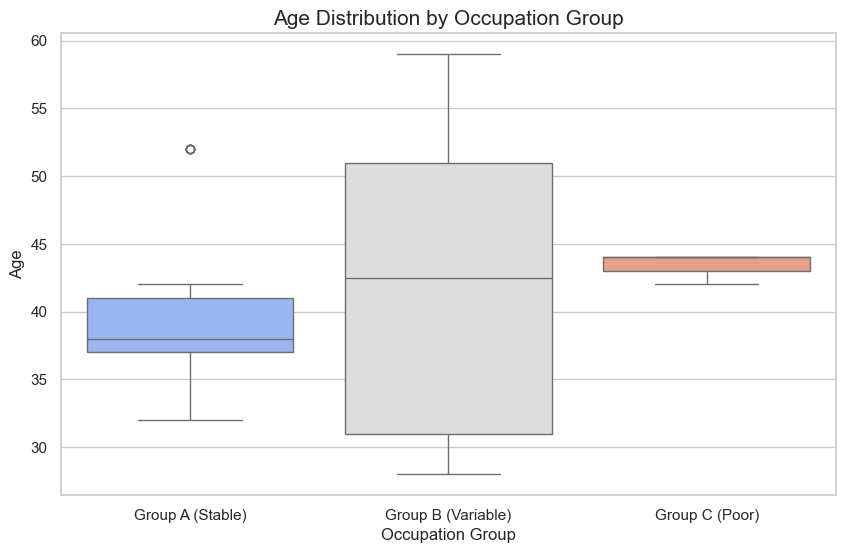

In [94]:
# Age Distribution by Group (Is age a factor?)
plt.figure(figsize=(10, 6))
sns.boxplot(x='Occupation Group', y='Age', data=df_groups, palette='coolwarm', order=['Group A (Stable)', 'Group B (Variable)', 'Group C (Poor)'])
plt.title('Age Distribution by Occupation Group', fontsize=15)
plt.show()

## 10.5 Sleep Disorders
Group A: Aroud 85.7% of the participants' sleep disorders are normal.\
Group B: Aroud 45.1% of the participants' have sleep apnea, and 4.1% have insomnia.\
Group C: Aroud 90.6% of the participants' suffer from insomnia.

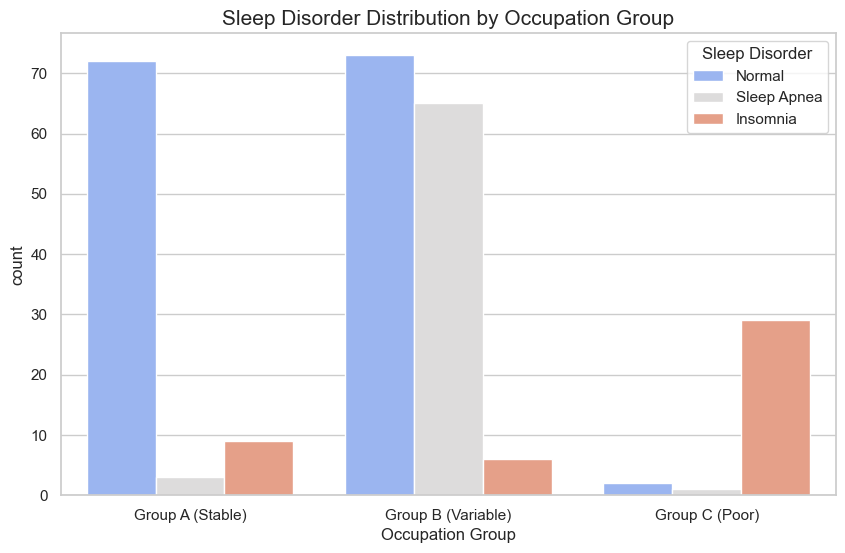

Sleep Disorder      Insomnia    Normal  Sleep Apnea
Occupation Group                                   
Group A (Stable)    0.107143  0.857143     0.035714
Group B (Variable)  0.041667  0.506944     0.451389
Group C (Poor)      0.906250  0.062500     0.031250


In [96]:
# Sleep Disorder Distribution by Group
plt.figure(figsize=(10, 6))
sns.countplot(x='Occupation Group', hue='Sleep Disorder', data=df_groups, palette='coolwarm', order=['Group A (Stable)', 'Group B (Variable)', 'Group C (Poor)'])
plt.title('Sleep Disorder Distribution by Occupation Group', fontsize=15)
plt.legend(title='Sleep Disorder', loc='upper right')
plt.show()

# Calculate percentage of disorders
disorder_counts = df_groups.groupby(['Occupation Group', 'Sleep Disorder']).size().unstack(fill_value=0)
disorder_props = disorder_counts.div(disorder_counts.sum(axis=1), axis=0)
print(disorder_props)